# Análisis Exploratorio de Datos 

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter
sns.set_style("whitegrid")

In [5]:
dataset_path = '../data/processed/train_clean.csv'
df = pd.read_csv(dataset_path)
df['Order Date'] = pd.to_datetime(df['Order Date'], errors='coerce')
df['Ship Date'] = pd.to_datetime(df['Ship Date'], errors='coerce')
df['Quarter'] = df['Order Date'].dt.to_period('Q')
print('Dataset cargado desde', dataset_path)
print('Shape:', df.shape)
print('Columnas:', df.columns.tolist())

Dataset cargado desde ../data/processed/train_clean.csv
Shape: (9800, 26)
Columnas: ['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Year', 'Month', 'Month Name', 'Nivel_Ventas', 'Month_Name', 'Quarter', 'Region_Category', 'Shipping_Time']


## 1. Inspección general
Se exploran la estructura del dataset, tipos de dato, primeras filas y estadísticas descriptivas.

In [6]:
print('Shape:', df.shape)
print('\nTipos de datos:' )
print(df.dtypes)
display(df.head())
display(df.describe(include='all').T)
print('\nValores únicos por columna categórica (top 20):')
cat_cols = df.select_dtypes(include=['object','category']).columns.tolist()
for c in cat_cols:
    print(f'- {c}:', df[c].nunique())

Shape: (9800, 26)

Tipos de datos:
Row ID                      int64
Order ID                      str
Order Date         datetime64[us]
Ship Date          datetime64[us]
Ship Mode                     str
Customer ID                   str
Customer Name                 str
Segment                       str
Country                       str
City                          str
State                         str
Postal Code                   str
Region                        str
Product ID                    str
Category                      str
Sub-Category                  str
Product Name                  str
Sales                     float64
Year                        int64
Month                       int64
Month Name                    str
Nivel_Ventas                  str
Month_Name                    str
Quarter             period[Q-DEC]
Region_Category               str
Shipping_Time               int64
dtype: object


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Product Name,Sales,Year,Month,Month Name,Nivel_Ventas,Month_Name,Quarter,Region_Category,Shipping_Time
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Bush Somerset Collection Bookcase,261.9600,2017,11,November,Alto,November,2017Q4,South - Furniture,3
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,2017,11,November,Alto,November,2017Q4,South - Furniture,3
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,Self-Adhesive Address Labels for Typewriters b...,14.6200,2017,6,June,Bajo,June,2017Q2,West - Office Supplies,4
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Bretford CR4500 Series Slim Rectangular Table,957.5775,2016,10,October,Alto,October,2016Q4,South - Furniture,7
4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Eldon Fold 'N Roll Cart System,22.3680,2016,10,October,Bajo,October,2016Q4,South - Office Supplies,7


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
Row ID,9800.0,NaN,NaN,NaN,4900.5,1.0,2450.75,4900.5,7350.25,9800.0,2829.160653
Order ID,9800,4922,CA-2018-100111,14,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Order Date,9800,NaN,NaN,NaN,2017-05-01 05:13:51.673469,2015-01-03 00:00:00,2016-05-24 00:00:00,2017-06-26 00:00:00,2018-05-15 00:00:00,2018-12-30 00:00:00,NaN
Ship Date,9800,NaN,NaN,NaN,2017-05-05 04:17:52.653061,2015-01-07 00:00:00,2016-05-27 18:00:00,2017-06-29 00:00:00,2018-05-19 00:00:00,2019-01-05 00:00:00,NaN
Ship Mode,9800,4,Standard Class,5859,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Customer ID,9800,793,WB-21850,35,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Customer Name,9800,793,William Brown,35,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Segment,9800,3,Consumer,5101,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Country,9800,1,United States,9800,NaN,NaN,NaN,NaN,NaN,NaN,NaN
City,9800,529,New York City,891,NaN,NaN,NaN,NaN,NaN,NaN,NaN



Valores únicos por columna categórica (top 20):
- Order ID: 4922
- Ship Mode: 4
- Customer ID: 793
- Customer Name: 793
- Segment: 3
- Country: 1
- City: 529
- State: 49
- Postal Code: 627
- Region: 4
- Product ID: 1861
- Category: 3
- Sub-Category: 17
- Product Name: 1849
- Month Name: 12
- Nivel_Ventas: 3
- Month_Name: 12
- Region_Category: 12


C:\Users\papit\AppData\Local\Temp\ipykernel_5076\59362372.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=['object','category']).columns.tolist()


## 2. Calidad de datos
Revisamos nulos, duplicados y la cardinalidad de variables categóricas relevantes.

In [7]:
print('Valores nulos por columna:')
display(df.isnull().sum().sort_values(ascending=False).head(20))
print('Duplicados totales:', df.duplicated().sum())
print('Cardinalidad variables categóricas:')
for c in ['Region','Category','Segment','Ship Mode']:
    if c in df.columns:
        print(f'{c}:', df[c].nunique())

Valores nulos por columna:


Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Year             0
Month            0
dtype: int64

Duplicados totales: 0
Cardinalidad variables categóricas:
Region: 4
Category: 3
Segment: 3
Ship Mode: 4


## 3. Análisis univariado
Se examinan las distribuciones de ventas y tiempos de envío, además de las frecuencias de las principales variables categóricas.

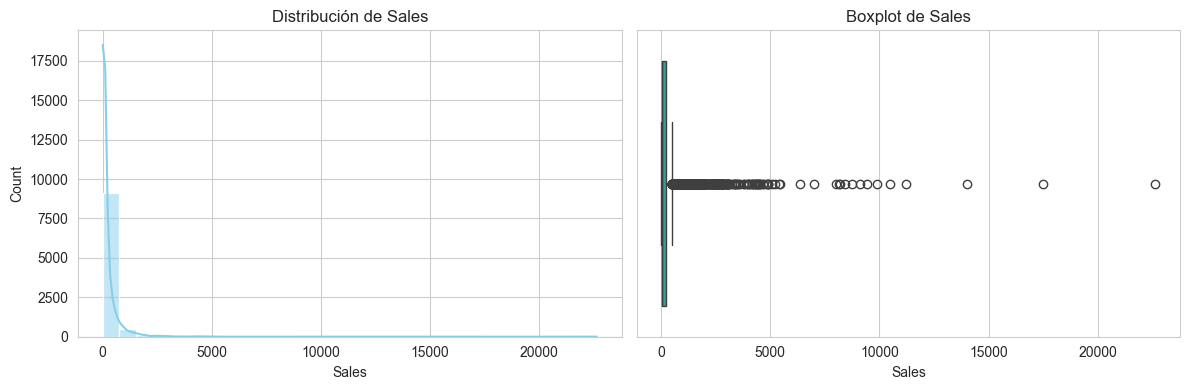

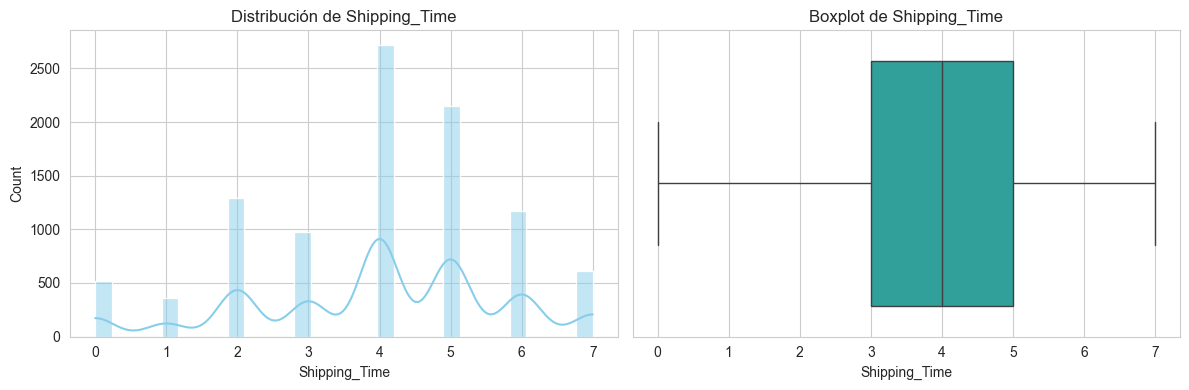

In [8]:
numerical_features = ['Sales','Shipping_Time']
for feature in numerical_features:
    if feature in df.columns:
        plt.figure(figsize=(12,4))
        plt.subplot(1,2,1)
        sns.histplot(df[feature].dropna(), kde=True, bins=30, color='skyblue')
        plt.title(f'Distribución de {feature}')
        plt.xlabel(feature)
        plt.subplot(1,2,2)
        sns.boxplot(x=df[feature], color='lightseagreen')
        plt.title(f'Boxplot de {feature}')
        plt.tight_layout()
        plt.show()

C:\Users\papit\AppData\Local\Temp\ipykernel_5076\2368359847.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.values, y=counts.index, palette='viridis')


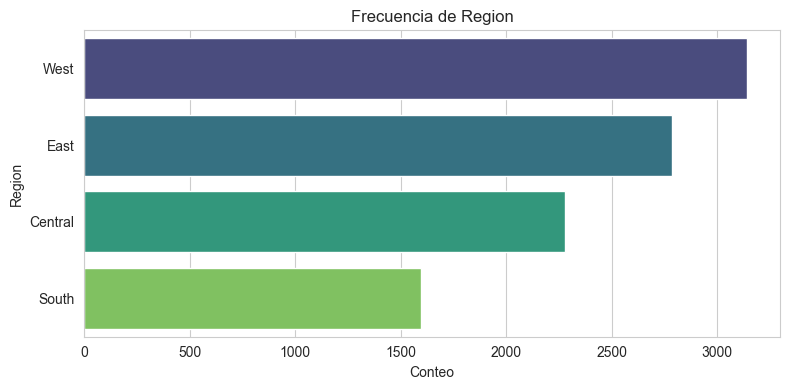

C:\Users\papit\AppData\Local\Temp\ipykernel_5076\2368359847.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.values, y=counts.index, palette='viridis')


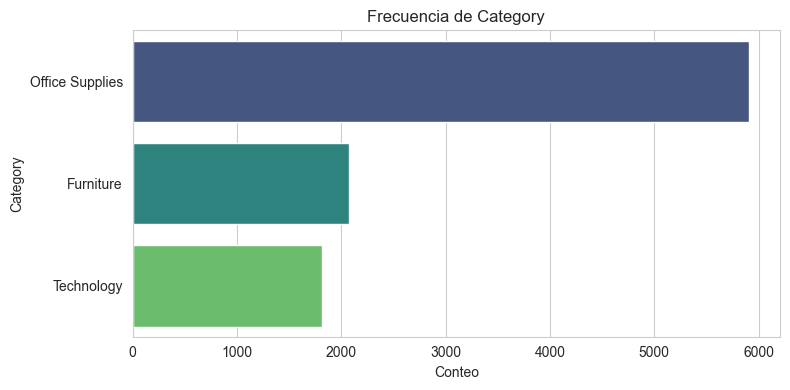

C:\Users\papit\AppData\Local\Temp\ipykernel_5076\2368359847.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.values, y=counts.index, palette='viridis')


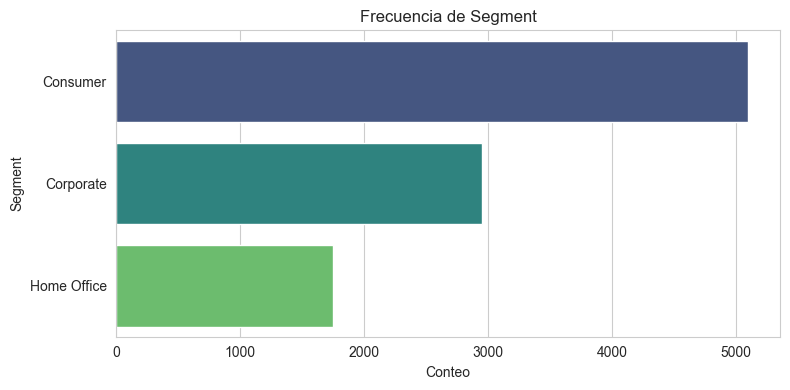

In [9]:
categorical_features = ['Region','Category','Segment']
for feature in categorical_features:
    if feature in df.columns:
        counts = df[feature].value_counts().nlargest(10)
        plt.figure(figsize=(8,4))
        sns.barplot(x=counts.values, y=counts.index, palette='viridis')
        plt.title(f'Frecuencia de {feature}')
        plt.xlabel('Conteo')
        plt.ylabel(feature)
        plt.tight_layout()
        plt.show()

## 4. Visualizaciones de comparación
Se utilizan barplots y barras agrupadas para comparar ventas por región, categoría y combinación región-categoría.

C:\Users\papit\AppData\Local\Temp\ipykernel_5076\3143163057.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=region_sales, x='Region', y='Sales', palette='coolwarm')


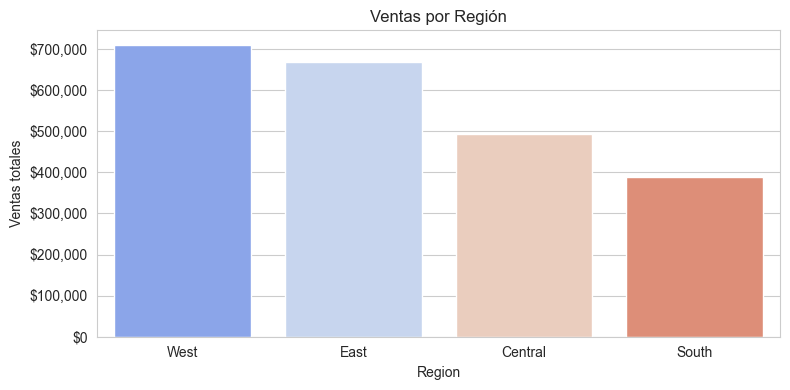

In [10]:
if 'Region' in df.columns and 'Sales' in df.columns:
    region_sales = df.groupby('Region')['Sales'].sum().sort_values(ascending=False).reset_index()
    plt.figure(figsize=(8,4))
    sns.barplot(data=region_sales, x='Region', y='Sales', palette='coolwarm')
    plt.title('Ventas por Región')
    plt.ylabel('Ventas totales')
    plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'${x:,.0f}'))
    plt.tight_layout()
    plt.show()

**Interpretación:** los valores muestran qué regiones son más fuertes en ventas y permiten priorizar recursos comerciales.

C:\Users\papit\AppData\Local\Temp\ipykernel_5076\3073808795.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=category_sales, x='Category', y='Sales', palette='magma')


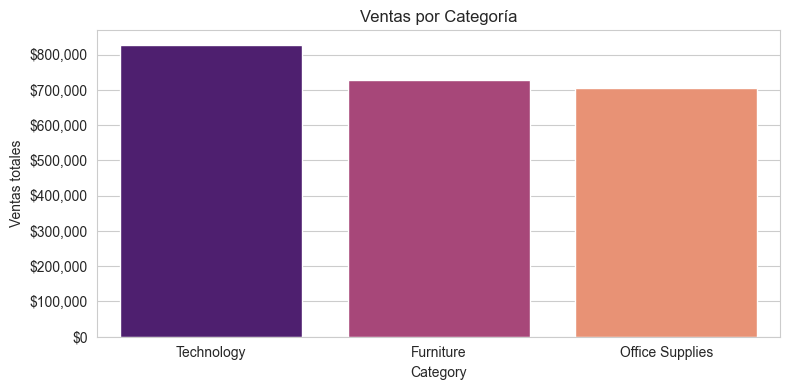

In [11]:
if 'Category' in df.columns and 'Sales' in df.columns:
    category_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False).reset_index()
    plt.figure(figsize=(8,4))
    sns.barplot(data=category_sales, x='Category', y='Sales', palette='magma')
    plt.title('Ventas por Categoría')
    plt.ylabel('Ventas totales')
    plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'${x:,.0f}'))
    plt.tight_layout()
    plt.show()

**Interpretación:** esta comparación identifica categorías con mayor aporte en ingresos.

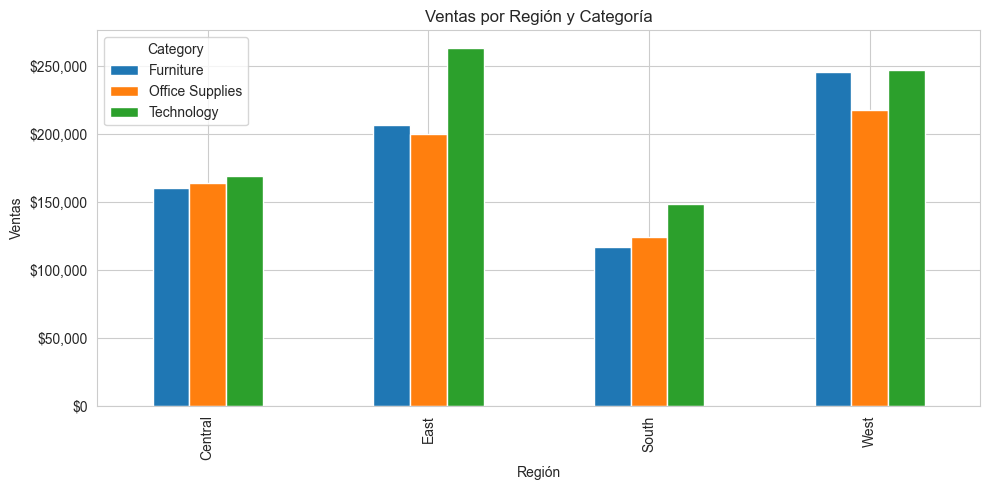

In [12]:
if {'Region','Category','Sales'}.issubset(df.columns):
    pivot = df.pivot_table(index='Region', columns='Category', values='Sales', aggfunc='sum').fillna(0)
    pivot.plot(kind='bar', figsize=(10,5))
    plt.title('Ventas por Región y Categoría')
    plt.ylabel('Ventas')
    plt.xlabel('Región')
    plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'${x:,.0f}'))
    plt.tight_layout()
    plt.show()

**Interpretación:** el gráfico muestra la composición de ventas por categoría en cada región.

## 5. Relación entre variables
Se exploran `Sales vs Shipping_Time` con scatterplot y la matriz de correlación con heatmap.

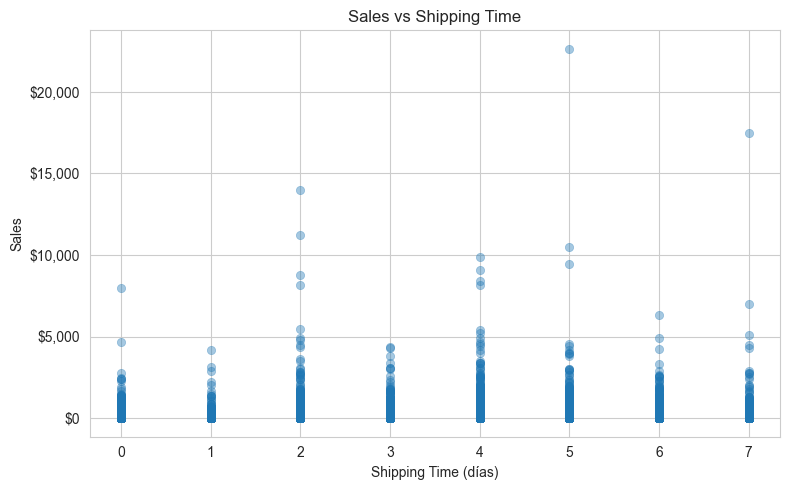

Correlación Sales vs Shipping_Time: -0.006


In [13]:
if {'Sales','Shipping_Time'}.issubset(df.columns):
    plt.figure(figsize=(8,5))
    sns.scatterplot(data=df, x='Shipping_Time', y='Sales', alpha=0.4, edgecolor=None)
    plt.title('Sales vs Shipping Time')
    plt.xlabel('Shipping Time (días)')
    plt.ylabel('Sales')
    plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'${x:,.0f}'))
    plt.tight_layout()
    plt.show()
    corr_value = df[['Sales','Shipping_Time']].corr().iloc[0,1]
    print('Correlación Sales vs Shipping_Time:', round(corr_value, 3))

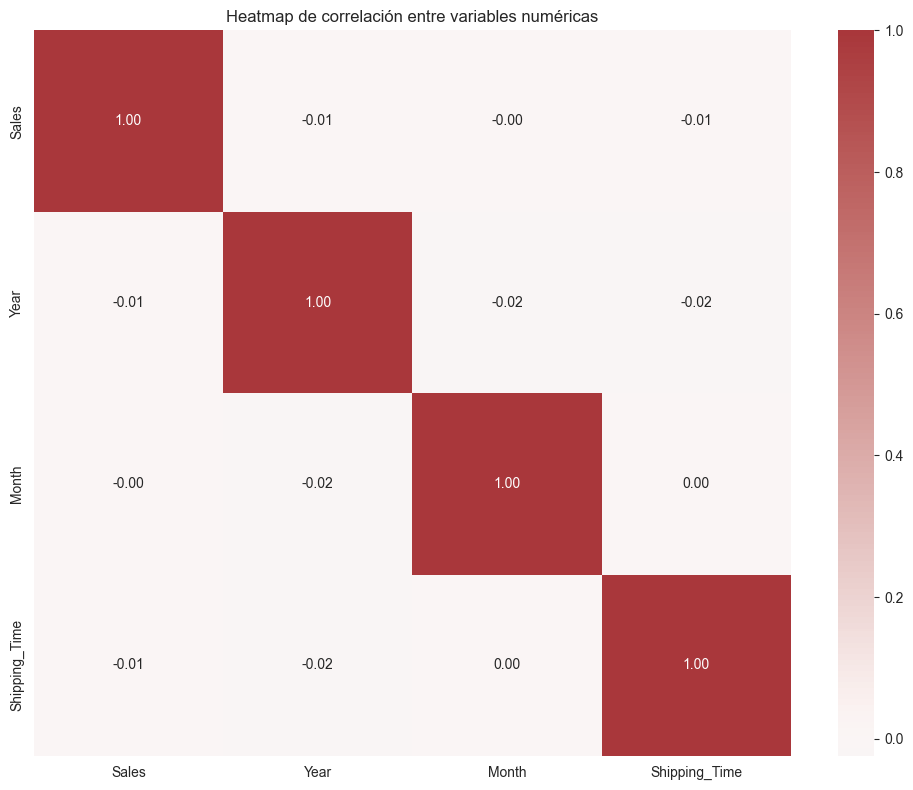

In [33]:
numeric_df = df.select_dtypes(include=[np.number])
numeric_df = numeric_df.loc[:, ~numeric_df.columns.str.contains('ID', case=False)]
plt.figure(figsize=(10,8))
corr = numeric_df.corr()
sns.heatmap(corr, annot=True, cmap='vlag', center=0, fmt='.2f')
plt.title('Heatmap de correlación entre variables numéricas')
plt.tight_layout()
plt.show()

## 6. Tendencia temporal
Se analiza el comportamiento de las ventas por mes y por trimestre utilizando line charts y barras.

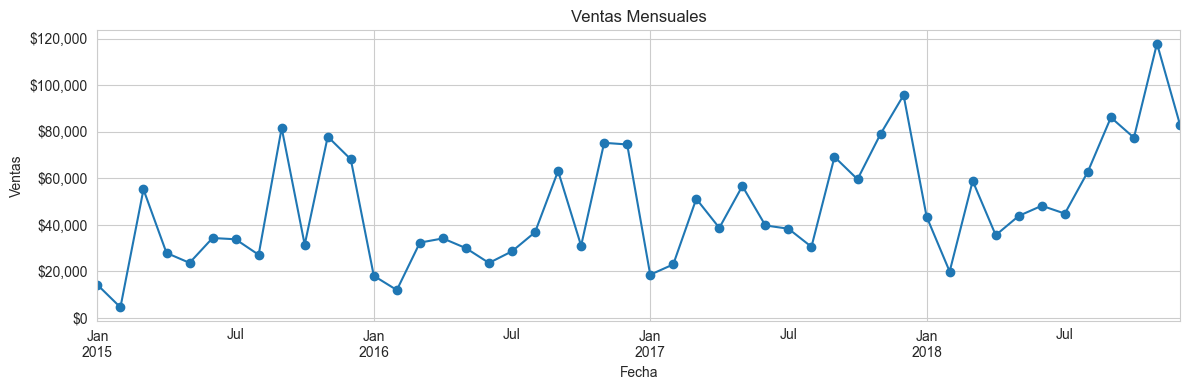

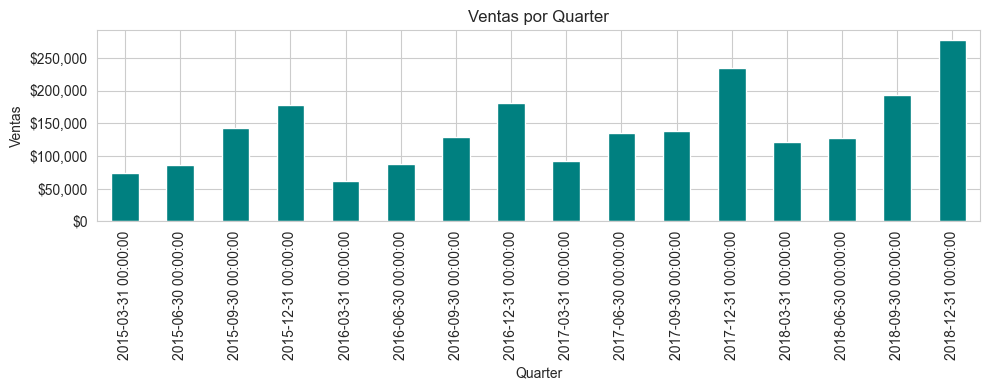

In [17]:
if 'Order Date' in df.columns and 'Sales' in df.columns:
    monthly = df.groupby(pd.Grouper(key='Order Date', freq='ME'))['Sales'].sum()
    quarterly = df.groupby(pd.Grouper(key='Order Date', freq='QE'))['Sales'].sum()
    plt.figure(figsize=(12,4))
    monthly.plot(marker='o')
    plt.title('Ventas Mensuales')
    plt.ylabel('Ventas')
    plt.xlabel('Fecha')
    plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'${x:,.0f}'))
    plt.tight_layout()
    plt.show()
    plt.figure(figsize=(10,4))
    quarterly.plot(kind='bar', color='teal')
    plt.title('Ventas por Quarter')
    plt.ylabel('Ventas')
    plt.xlabel('Quarter')
    plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'${x:,.0f}'))
    plt.tight_layout()
    plt.show()

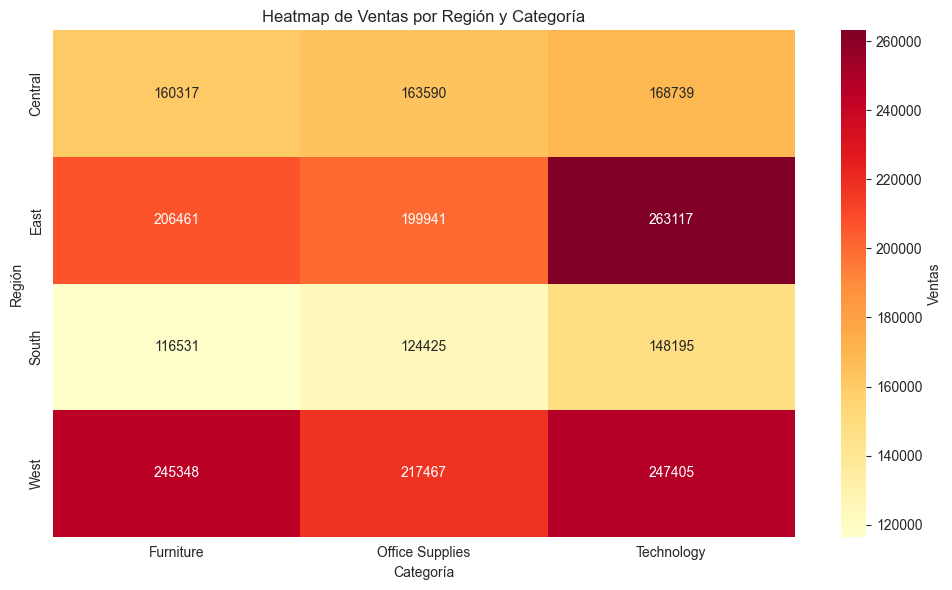

In [18]:
if {'Region','Category','Sales'}.issubset(df.columns):
    heatmap_pivot = df.pivot_table(index='Region', columns='Category', values='Sales', aggfunc='sum').fillna(0)
    plt.figure(figsize=(10,6))
    sns.heatmap(heatmap_pivot, annot=True, fmt='.0f', cmap='YlOrRd', cbar_kws={'label': 'Ventas'})
    plt.title('Heatmap de Ventas por Región y Categoría')
    plt.xlabel('Categoría')
    plt.ylabel('Región')
    plt.tight_layout()
    plt.show()

### Ventas en el Tiempo (Mensual)

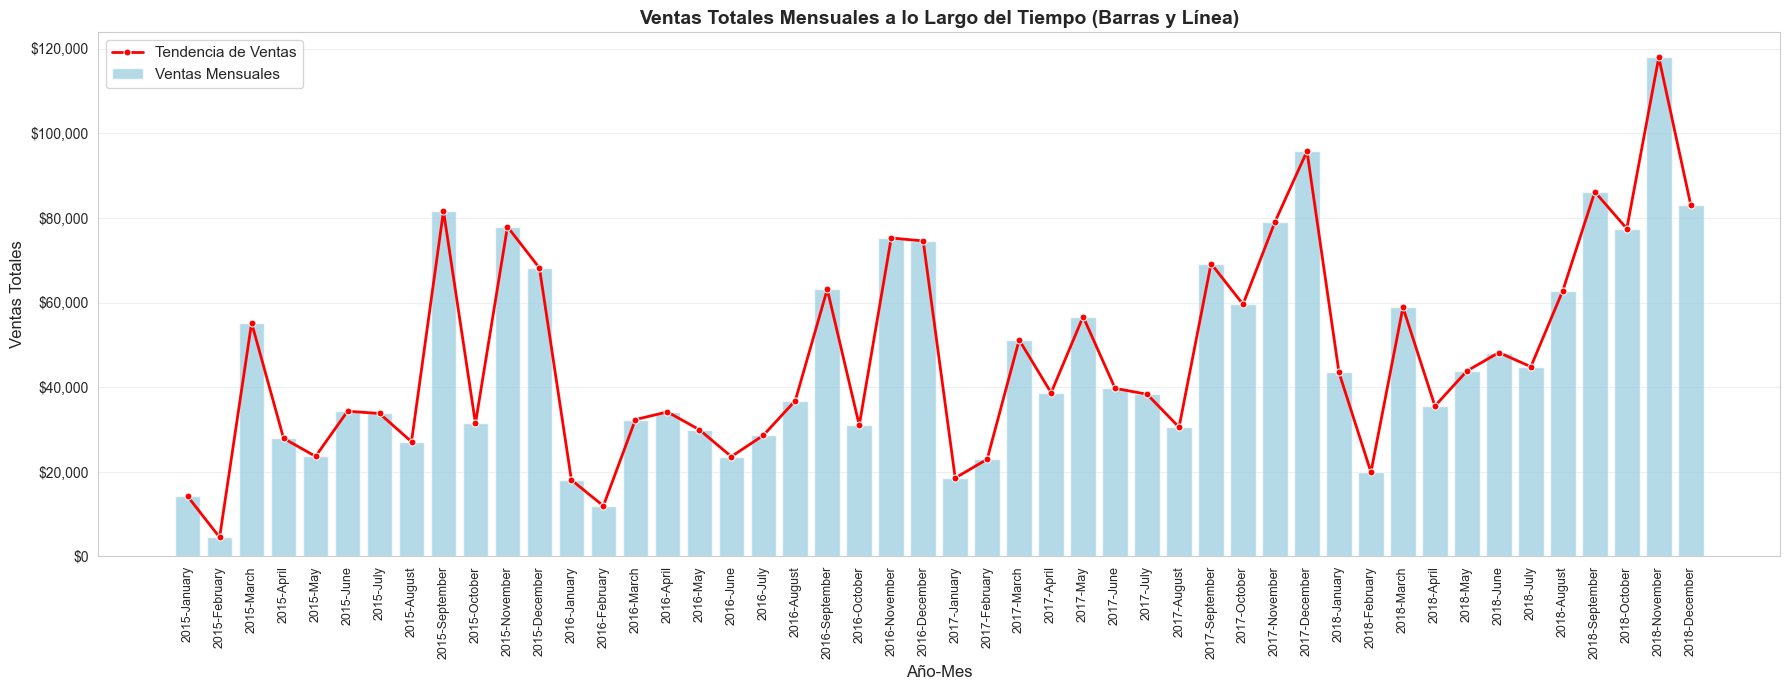

In [27]:
if 'Order Date' in df.columns and 'Sales' in df.columns:
    # Preparar datos: extraer Year y Month_Name
    sales_over_time = df.copy()
    sales_over_time['Year'] = sales_over_time['Order Date'].dt.year
    sales_over_time['Month_Name'] = sales_over_time['Order Date'].dt.month_name()
    
    sales_over_time = sales_over_time.groupby(['Year', 'Month_Name'])['Sales'].sum().reset_index()
    sales_over_time['YearMonth'] = sales_over_time['Year'].astype(str) + '-' + sales_over_time['Month_Name']
    
    # Ordenar correctamente los meses
    month_order = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']
    sales_over_time['Month_Num'] = pd.Categorical(sales_over_time['Month_Name'], categories=month_order, ordered=True).codes
    sales_over_time = sales_over_time.sort_values(by=['Year', 'Month_Num'])
    
    # Crear visualización
    plt.figure(figsize=(18, 7))
    
    sns.barplot(data=sales_over_time, x='YearMonth', y='Sales', color='skyblue', alpha=0.7, label='Ventas Mensuales')
    
    sns.lineplot(data=sales_over_time, x='YearMonth', y='Sales', color='red', marker='o', markersize=5, linewidth=2, label='Tendencia de Ventas')
    
    plt.title('Ventas Totales Mensuales a lo Largo del Tiempo (Barras y Línea)', fontsize=14, fontweight='bold')
    plt.xlabel('Año-Mes', fontsize=12)
    plt.ylabel('Ventas Totales', fontsize=12)
    plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'${x:,.0f}'))
    plt.xticks(rotation=90, fontsize=9)
    plt.grid(True, alpha=0.3, axis='y')
    plt.legend(fontsize=11)
    plt.tight_layout()
    plt.show()